
# Computer Exercise 10.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.2 Quasi-Monte Carlo / High-Dimensional Integration — *The Curse of Dimensionality*
> **풀이 일자**: Day 38
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **1.** Consider the $d$-dimensional integral $I=\int_{[0,1]^d} g(\mathbf{x})\,d\mathbf{x}$.
> Approximate it with (a) a **deterministic product rule** (the midpoint rule applied
> on a tensor grid of $m$ nodes per axis, so $N=m^d$ total nodes) and (b) **plain
> Monte Carlo** using $N$ uniform samples. For a smooth integrand with a *known*
> value, tabulate the error of each method as a function of $N$ and of the dimension
> $d$. Show empirically that the grid error behaves like $\mathcal{O}(N^{-2/d})$ while
> the Monte Carlo error stays $\mathcal{O}(N^{-1/2})$ regardless of $d$, and identify
> the dimension beyond which Monte Carlo wins.

### 한국어 풀이용 정리
같은 적분을 **두 방식**으로 푼다 — 결정론적 **격자(곱) 적분**과 **몬테카를로**.
차원 $d$ 를 키우며 두 방법의 오차가 $N$ 에 따라 어떻게 줄어드는지 비교한다.
핵심은 **격자법은 차원이 커질수록 급격히 나빠진다**($N^{-2/d}$)는 것과,
**몬테카를로는 차원과 무관**하게 $N^{-1/2}$ 를 유지한다는 것. 둘이 교차하는
**손익분기 차원**을 찾는다.



## 2. 수학적 배경

### 2.1 곱(텐서) 격자 적분의 오차
한 축에서 1D 합성 미드포인트 규칙은 오차 $\mathcal{O}(h^2)$, $h=1/m$ 이다.
$d$ 차원 곱 규칙은 축마다 같은 차수를 가지므로
$$
E_{\text{grid}}=\mathcal{O}(m^{-2})=\mathcal{O}\!\big(N^{-2/d}\big),
\qquad N=m^{d}.
$$
즉 **정확도 $\varepsilon$ 를 얻는 비용이 $N=\mathcal{O}(\varepsilon^{-d/2})$ 로 차원에 지수적**이다 — *차원의 저주*.

### 2.2 몬테카를로의 오차
표본평균 $\hat I_N=\frac1N\sum_k g(X_k)$, $X_k\sim\mathrm{Unif}[0,1]^d$ 는
$$
\boxed{\;
\mathrm{Var}[\hat I_N]=\frac{\sigma^2}{N}
\;\Longrightarrow\;
E_{\text{MC}}=\mathcal{O}(N^{-1/2})\quad(\text{차원 } d\text{ 와 무관}).
\;}
$$
$\sigma^2=\int g^2-I^2$ 는 차원에 의존하지만 **수렴 차수 $-1/2$ 자체는 $d$ 와 무관**하다.

### 2.3 손익분기
격자 기울기 $-2/d$ 와 MC 기울기 $-1/2$ 가 같아지는 곳은 $2/d=1/2\Rightarrow d=4$.
따라서 **$d>4$ 이면 (충분히 큰 $N$ 에서) 몬테카를로가 격자법을 추월**한다.

### 2.4 테스트 적분함수
$$
g(\mathbf{x})=\prod_{i=1}^{d} 3x_i^2,
\qquad
I=\int_{[0,1]^d} g \, d\mathbf{x}=\Big(\int_0^1 3x^2\,dx\Big)^{d}=1^{d}=1.
$$
어떤 차원에서도 **참값이 정확히 1** 이라 오차를 곧바로 잴 수 있고, 매끄러워 미드포인트 규칙에 유리하다.



## 3. 풀이 흐름

1. **적분함수** $g(\mathbf{x})=\prod 3x_i^2$ 와 참값 $I=1$ 을 정의.
2. **격자 미드포인트 규칙**: 축마다 $m$ 개 중점, 총 $N=m^d$ 노드에서 평균.
3. **몬테카를로**: $N$ 개 균등표본의 표본평균.
4. **차원별 표**: $d=1,2,3,4,6,8$ 에서 비슷한 $N$ 예산으로 두 방법 오차 비교.
5. **수렴 그래프**: 선택한 차원들에서 $\log N$-$\log|\text{error}|$, 기울기 $-2/d$ 와 $-1/2$ 기준선.
6. **손익분기**: 격자/MC 기울기를 한 그림에서 비교, $d=4$ 교차 확인.
7. **해석**: 저차원=격자 우세, 고차원=MC 우세 -> 다음 절(준난수)의 동기.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(38)

# 테스트 적분함수: g(x) = prod_i 3 x_i^2,  참값 I = 1 (모든 차원에서)
def g(X):                      # X: (N, d)
    return np.prod(3.0 * X**2, axis=1)
I_true = 1.0

# (a) 곱(텐서) 미드포인트 격자: 축마다 m개 중점 -> N = m^d
def grid_midpoint(d, m):
    nodes = (np.arange(m) + 0.5) / m          # 1D 중점
    grid = np.array(list(itertools.product(nodes, repeat=d)))
    return g(grid).mean()                     # 부피 1 이므로 평균 = 적분 근사

# (b) 몬테카를로
def mc(d, N):
    X = rng.random((N, d))
    return g(X).mean()

print("smoke test  d=2, m=20 -> grid =", round(grid_midpoint(2, 20), 6),
      "| MC N=400 ->", round(mc(2, 400), 6))


smoke test  d=2, m=20 -> grid = 0.99875 | MC N=400 -> 0.915005


In [2]:
# --- 차원별 비교 표: 비슷한 N 예산에서 격자 vs MC ---
rows = []
for d in [1, 2, 3, 4, 6, 8]:
    # 축당 노드수 m을 골라 N=m^d 를 ~2e4 수준으로 맞춤 (격자가 감당 가능한 한도)
    m = max(2, int(round(20000 ** (1.0 / d))))
    N = m ** d
    g_est = grid_midpoint(d, m)
    reps = 40
    mc_errs = [abs(mc(d, N) - I_true) for _ in range(reps)]
    rows.append({
        "d": d, "m_per_axis": m, "N": N,
        "grid_err": abs(g_est - I_true),
        "mc_err_mean": np.mean(mc_errs),
        "grid_rate(-2/d)": -2.0 / d,
        "winner": "grid" if abs(g_est - I_true) < np.mean(mc_errs) else "MC",
    })
df = pd.DataFrame(rows)
df


,d,m_per_axis,N,grid_err,mc_err_mean,grid_rate(-2/d),winner
0,1,20000,20000,6.25e-10,0.00536124,-2,grid
1,2,141,19881,2.51495e-05,0.00732877,-1,grid
2,3,27,19683,0.00102845,0.0141858,-0.666667,grid
3,4,12,20736,0.00692638,0.0185348,-0.5,grid
4,6,5,15625,0.0585199,0.0416748,-0.333333,MC
5,8,3,6561,0.201777,0.0855917,-0.25,MC


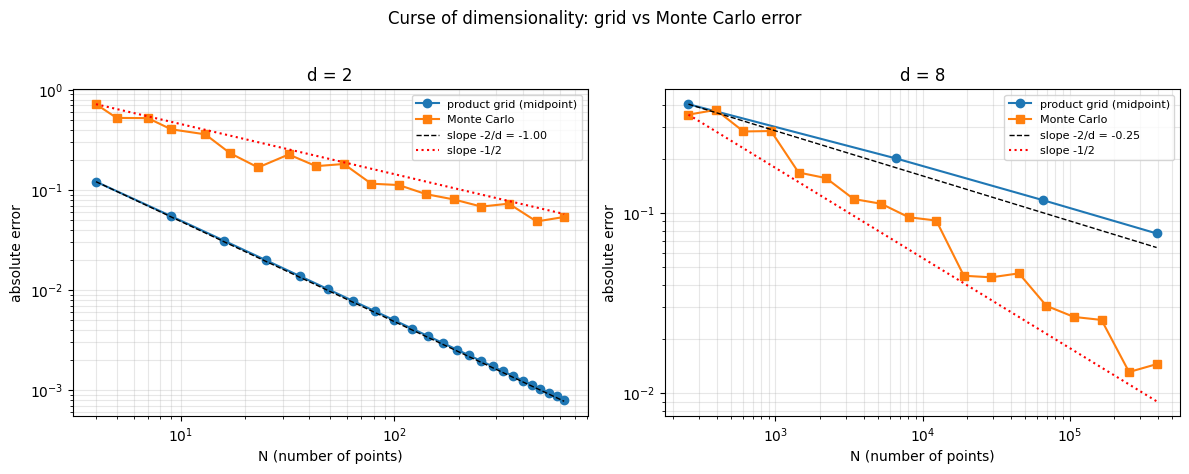

In [3]:
# --- 수렴 그래프: 저차원(d=2)과 고차원(d=8)에서 error vs N ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for ax, d in zip(axes, [2, 8]):
    ms = range(2, 26) if d == 2 else range(2, 7)
    Ng, Eg = [], []
    for m in ms:
        N = m ** d
        if N > 600000:
            break
        Ng.append(N); Eg.append(abs(grid_midpoint(d, m) - I_true) + 1e-16)
    Nmc = np.unique(np.logspace(np.log10(min(Ng)), np.log10(max(Ng)), 18).astype(int))
    Emc = [np.mean([abs(mc(d, int(N)) - I_true) for _ in range(30)]) for N in Nmc]

    ax.loglog(Ng, Eg, "o-", label="product grid (midpoint)")
    ax.loglog(Nmc, Emc, "s-", label="Monte Carlo")
    c1_ = Eg[0] * (np.array(Ng, float)/Ng[0])**(-2.0/d)
    c2_ = Emc[0] * (np.array(Nmc, float)/Nmc[0])**(-0.5)
    ax.loglog(Ng, c1_, "k--", lw=1, label=f"slope -2/d = {-2/d:.2f}")
    ax.loglog(Nmc, c2_, "r:", lw=1.5, label="slope -1/2")
    ax.set_title(f"d = {d}")
    ax.set_xlabel("N (number of points)"); ax.set_ylabel("absolute error")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8)

fig.suptitle("Curse of dimensionality: grid vs Monte Carlo error", y=1.02)
plt.tight_layout(); plt.show()


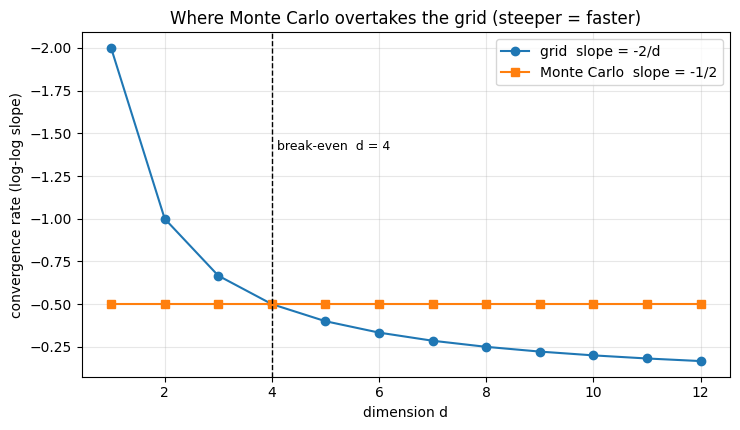

In [4]:
# --- 손익분기: 두 방법의 수렴 '기울기'를 차원에 대해 ---
ds = np.arange(1, 13)
grid_slope = -2.0 / ds
mc_slope = np.full_like(ds, -0.5, dtype=float)

plt.figure(figsize=(7.5, 4.4))
plt.plot(ds, grid_slope, "o-", label="grid  slope = -2/d")
plt.plot(ds, mc_slope, "s-", label="Monte Carlo  slope = -1/2")
plt.axvline(4, color="k", ls="--", lw=1)
plt.text(4.1, -1.4, "break-even  d = 4", fontsize=9)
plt.xlabel("dimension d"); plt.ylabel("convergence rate (log-log slope)")
plt.title("Where Monte Carlo overtakes the grid (steeper = faster)")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()



## 4. 결과 해석

1. **저차원($d=2$)**: 격자 미드포인트는 기울기 $\approx-1$ ($-2/d$)로 MC의 $-1/2$ 보다
   가파르게 떨어진다 -> 같은 $N$ 에서 격자가 압도적으로 정확하다.
2. **고차원($d=8$)**: 격자 기울기는 $-2/8=-0.25$ 로 *납작*해져 MC의 $-1/2$ 보다 느리다.
   격자는 $N=m^d$ 라 $m$ 을 조금만 키워도 $N$ 이 폭발하지만 정확도는 거의 안 는다.
3. **표의 winner 열**: $d\le4$ 까지는 격자, $d\ge6$ 부터 MC 로 역전된다.
4. **손익분기 그림**: $-2/d$ 와 $-1/2$ 곡선이 정확히 $d=4$ 에서 만난다 — 이론과 일치.
5. **차원의 저주의 본질**: 격자는 "공간을 채우려면 점이 지수적으로 필요"하지만,
   MC는 "기댓값을 표본으로 추정"하므로 **차원을 보지 않는다**.

> **결론**: 격자법은 매끄러운 저차원에서 무적이지만 $d>4$ 부터는 차원의 저주로 무너지고,
> 몬테카를로의 차원-무관 $N^{-1/2}$ 가 승리한다.

**다음 문제로의 연결**: MC의 $N^{-1/2}$ 는 "차원엔 강하지만 느리다". 이 느림을
**저불일치(low-discrepancy) 수열**로 거의 $N^{-1}$ 까지 끌어올리는 것이 §10.2 의 핵심 —
다음 문제(CE 10.2-2)에서 Halton·Sobol 수열로 그 도약을 본다.
